* On utilise une régression linéaire
simple pour modéliser la relation entre :
    * X : années d’expérience
    * y : salaire
* Le modèle apprend une droite :
  ŷ = β₀ + β₁ × x
* Le score R² ≈ 0.89 signifie que le modèle explique 89% de la variance → très bon modèle.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving salaries.csv to salaries.csv


In [ ]:
# https://www.youtube.com/watch?v=c_1a2KZUVe8
# Importation des bibliothèques nécessaires
import pandas as pd
import matplotlib.pyplot as plt # bibliothique pour la  visualisation


In [ ]:
# Chargement du dataset depuis un fichier CSV
import io
df = pd.read_csv(io.BytesIO(uploaded['salaries.csv'])) # read the dataset from salaries.csv

# Afficher les 5 premières lignes du dataset pour comprendre sa structure
df.head()

,years_of_experience,salary
0,5,3150
1,9,3787
2,4,2991
3,10,4551
4,8,3540


In [ ]:
# Séparation des variables indépendantes (X) et dépendantes (y)

x = df.iloc[:,:-1].values # toutes les colonnes sauf la dernière (Salary)
x[0:3]

array([[5],
       [9],
       [4]])

In [ ]:
y = df.iloc[:,-1].values # dernière colonne (Salary)

# Afficher les 3 premières valeurs de y
y[0:3]

array([3150, 3787, 2991])

/tmp/ipykernel_4126/777489161.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


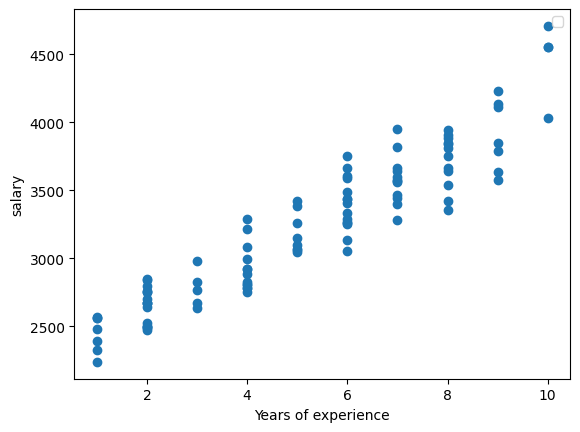

In [ ]:
# Visualisation des données sous forme de nuage de points
plt.scatter(x, y) # visualise the data
# Nom de l’axe X
plt.xlabel("Years of experience")
# Nom de l’axe Y
plt.ylabel("salary") # rename the axis Y

# Affichage de la légende (utile si plusieurs courbes)
plt.legend()


In [ ]:
# Importation de la fonction pour diviser les données
from sklearn.model_selection import train_test_split

# Division des données en ensemble d'entraînement (80%) et de test (20%)
x_train, x_test, y_train, Y_test= train_test_split(x,y, test_size=0.2, random_state=0) # 20% for test size

# Afficher la taille des données d'entraînement (X)
x_train.shape
# Afficher la taille des données de test (X)
x_test.shape
# Afficher la taille des données de test (y)
Y_test.shape

(20,)

In [ ]:
# Importation du modèle de régression linéaire
from sklearn.linear_model import LinearRegression # bibotheque pour la modélisation

# Création du modèle
model= LinearRegression()

In [ ]:
#  Fonction Coût:  LinearRegression() minimise en interne le MSE (Mean Squared Error)

# Entraînement du modèle sur les données d'entraînement
model.fit(x_train, y_train)# functoion pour trainer le model

LinearRegression()

In [ ]:
# Prédiction des salaires pour des années d'expérience données
model.predict([[7], [5], [3.5]]) # it give the predicted values of the salary for 7 and 5 and 3.5 years

array([3587.02214514, 3201.70090715, 2912.70997866])

In [ ]:
# Prédiction sur les données de test
Y_pred= model.predict(x_test) # it give the predicted values of the salary by training model
# Affichage des valeurs prédites
Y_pred

array([2816.37966916, 3779.68276414, 3009.04028815, 3779.68276414,
       3587.02214514, 2623.71905016, 4165.00400213, 3201.70090715,
       3587.02214514, 3009.04028815, 2431.05843116, 3587.02214514,
       3201.70090715, 3587.02214514, 3394.36152615, 3587.02214514,
       3779.68276414, 2623.71905016, 3201.70090715, 2816.37966916])

In [ ]:
# Calcul de l’erreur entre les valeurs réelles et prédites
error = Y_pred - Y_test # measure the error with the value in the testing process and after the prediction process

# Affichage des erreurs
error

array([ 147.37966916,  118.68276414,   18.04028815,   28.68276414,
         12.02214514,  -48.28094984, -542.99599787,  131.70090715,
        -11.97785486,  125.04028815,   42.05843116,  190.02214514,
        141.70090715,  306.02214514,  125.36152615,  -50.97785486,
        141.68276414,  -74.28094984,  102.70090715,   49.37966916])

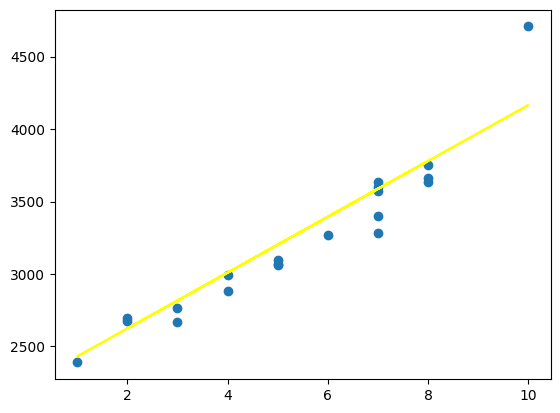

In [ ]:
# Visualisation des données de test
plt.scatter(x_test, Y_test)
# Tracé de la droite de régression (prédictions)
plt.plot(x_test,Y_pred, color='yellow')

In [ ]:
# Optimisation du Modèle
# R² = 0.89 indique que le modèle explique 89% de la variance des salaires — c'est un très bon résultat pour une régression simple à 1 seule variable.

# Importation de la métrique R² pour évaluer le modèle
from sklearn.metrics import r2_score

# Calcul du score R² (coefficient de détermination)
r2 = r2_score(Y_test,Y_pred)# a function give me the accuracy of the model is 89% is considered a very good
# Affichage du score R²
r2

# β1​=∑(xi​−xˉ)(yi​−yˉ)/∑(xi​−xˉ)^2​​,β0​=yˉ​−β1​xˉ


0.8921287198195745

In [ ]:
# Affichage de l’ordonnée à l’origine (β0)
print(model.intercept_)

# Affichage du coefficient directeur (β1)
print(model.coef_)
# donc y = 192.66 *x + 2238.39

2238.397812166488
[192.660619]
